In [26]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

# In Cell 1 (Setup and Imports)
from scipy.spatial.transform import Rotation

# Configure JAX for 64-bit precision for better simulation accuracy
from jax import config
config.update("jax_enable_x64", True)

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# --- Import from your custom modules ---
try:
    from utils import hat, vee, odeint_fixed_step
    from dynamics import prior
except ImportError:
    print("Please ensure these files are in the same directory as this notebook.")

In [27]:
def simulation_ode(z, t, k_R, K_mat, Lambda_mat, reference_func, dt):
    """
    Calculates the derivatives of the system state for the ODE solver.
    This version uses a tangent vector for the desired yaw.
    """
    # 1. Unpack the state vector
    x, R_flatten, Omega_state = z
    q, dq = x[:3], x[3:]
    R = R_flatten.reshape((3, 3))
    
    # 2. Get reference trajectory values at time t
    r, dr, ddr = reference_func(t)
    
    # 3. Non-adaptive controller to calculate desired force u_d
    e, de = q - r, dq - dr
    s = de + Lambda_mat @ e
    v, dv = dr - Lambda_mat @ e, ddr - Lambda_mat @ de
    H, C, g, B = prior(q, dq)
    tau = H @ dv + C @ v + g - K_mat @ s
    u_d = jnp.linalg.solve(B, tau)

    # 4. Direct Bodyrate Control Logic
    # Compute desired thrust direction (b_3d)
    f_d = jnp.linalg.norm(u_d)
    b_3d = u_d / (f_d + 1e-6)

    # --- MODIFICATION START ---
    # The desired "forward" direction is the tangent to the circle (the velocity vector).
    b_1d_desired = dr / (jnp.linalg.norm(dr) + 1e-6)
    
    # The body y-axis is orthogonal to both the thrust and desired forward vectors.
    b_2d_temp = jnp.cross(b_3d, b_1d_desired)
    b_2d = b_2d_temp / (jnp.linalg.norm(b_2d_temp) + 1e-6)
    
    # The final body x-axis is derived to be orthogonal to both b_2d and b_3d.
    b_1d = jnp.cross(b_2d, b_3d)
    
    R_d = jnp.column_stack((b_1d, b_2d, b_3d))
    # --- MODIFICATION END ---

    # Compute attitude error and the body rate command (Omega_cmd)
    e_R = 0.5 * vee(R_d.T @ R - R.T @ R_d)
    Omega_cmd = -k_R * e_R

    # 5. Simulate the physical dynamics
    dR = R @ hat(Omega_cmd)
    dR_flatten = dR.flatten()
    u_applied = f_d * R @ jnp.array([0., 0., 1.])
    ddq = jnp.linalg.solve(H, u_applied - C @ dq - g)
    dx = jnp.concatenate((dq, ddq))
    
    # 6. Force the Omega state to track the command
    dOmega = (Omega_cmd - Omega_state) / dt
    
    return dx, dR_flatten, dOmega

## A wrapper to handle the pytree (tuple) state for the JAX integrator
@partial(jax.jit, static_argnums=(5, 7)) # <-- FIX IS HERE
def jax_flatten_wrapper(z_flat, t, k_R, K_mat, Lambda_mat, reference_func, dt, z_unravel_func):
    # Un-flatten the state vector into a pytree
    z_tree = z_unravel_func(z_flat)
    # Call the main ODE function
    dz_tree = simulation_ode(z_tree, t, k_R, K_mat, Lambda_mat, reference_func, dt)
    # Flatten the output derivatives for the integrator
    return jnp.concatenate(jax.tree_util.tree_leaves(dz_tree))

In [28]:
## --- Trajectory Definition ---
RADIUS = 2.0
ALTITUDE = 1.5
PERIOD = 20.0  # seconds to complete one circle
OMEGA_TRAJ = 2 * jnp.pi / PERIOD

@jax.jit
def circle_reference_func(t):
    """Returns the desired position, velocity, and acceleration for a circle."""
    # Position
    r_x = RADIUS * jnp.cos(OMEGA_TRAJ * t)
    r_y = RADIUS * jnp.sin(OMEGA_TRAJ * t)
    r_z = ALTITUDE
    r = jnp.array([r_x, r_y, r_z])
    
    # Velocity
    dr_x = -RADIUS * OMEGA_TRAJ * jnp.sin(OMEGA_TRAJ * t)
    dr_y = RADIUS * OMEGA_TRAJ * jnp.cos(OMEGA_TRAJ * t)
    dr_z = 0.0
    dr = jnp.array([dr_x, dr_y, dr_z])
    
    # Acceleration
    ddr_x = -RADIUS * OMEGA_TRAJ**2 * jnp.cos(OMEGA_TRAJ * t)
    ddr_y = -RADIUS * OMEGA_TRAJ**2 * jnp.sin(OMEGA_TRAJ * t)
    ddr_z = 0.0
    ddr = jnp.array([ddr_x, ddr_y, ddr_z])
    
    return r, dr, ddr

## --- Simulation Parameters ---
T_FINAL = PERIOD  # Simulate for one full period
DT = 0.01         # Simulation timestep

## --- Controller Gains ---
# These are fixed gains for our non-adaptive controller.
k_R = jnp.array([2.0, 2.0, 1.0]) # Attitude P-gains for bodyrate command
K_mat = jnp.diag(jnp.array([2.0, 2.0, 3.0])) # Pos/Vel tracking gains
Lambda_mat = jnp.diag(jnp.array([1.0, 1.0, 1.0])) # Pos/Vel tracking gains

## --- Initial Conditions ---
# Start the drone at the beginning of the trajectory
r0, dr0, _ = circle_reference_func(0.0)
x0 = jnp.concatenate([r0, dr0])
R0 = jnp.eye(3)
R0_flatten = R0.flatten()
Omega0 = jnp.zeros(3)

# Assemble the initial state vector z0 as a pytree (tuple)
z0_tree = (x0, R0_flatten, Omega0)
# Flatten the initial state and get the un-flattening function for use in the ODE wrapper
z0_flat, z_unravel_func = jax.flatten_util.ravel_pytree(z0_tree)

In [29]:
print("Starting simulation...")

# Create a partial function for the ODE solver
# This wraps our main ODE function with the constant parameters
ode_for_solver = partial(
    jax_flatten_wrapper,
    k_R=k_R,
    K_mat=K_mat,
    Lambda_mat=Lambda_mat,
    reference_func=circle_reference_func,
    dt=DT,
    z_unravel_func=z_unravel_func
)

# Run the fixed-step integrator
z_history_flat, ts = odeint_fixed_step(ode_for_solver, z0_flat, 0.0, T_FINAL, DT)

# Un-flatten the results for easier analysis
z_history = jax.vmap(z_unravel_func)(z_history_flat)
x_hist, R_flat_hist, Omega_hist = z_history

print("Simulation complete!")

Starting simulation...
Simulation complete!


📊 Generating plots...


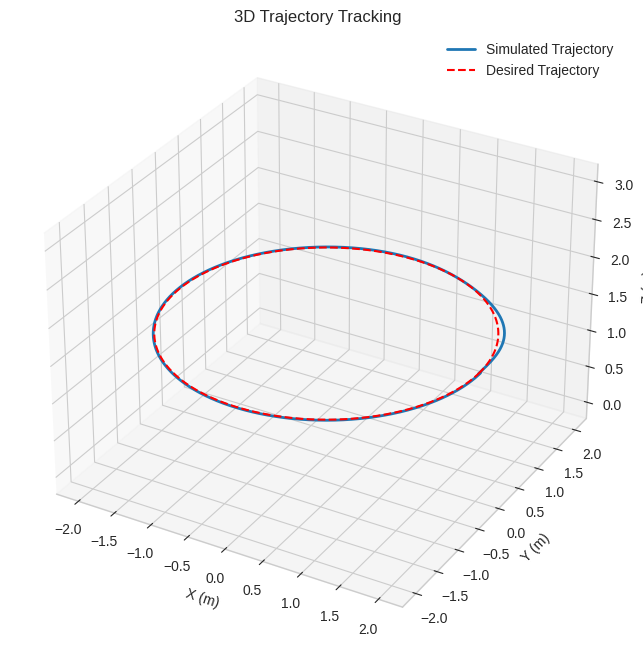

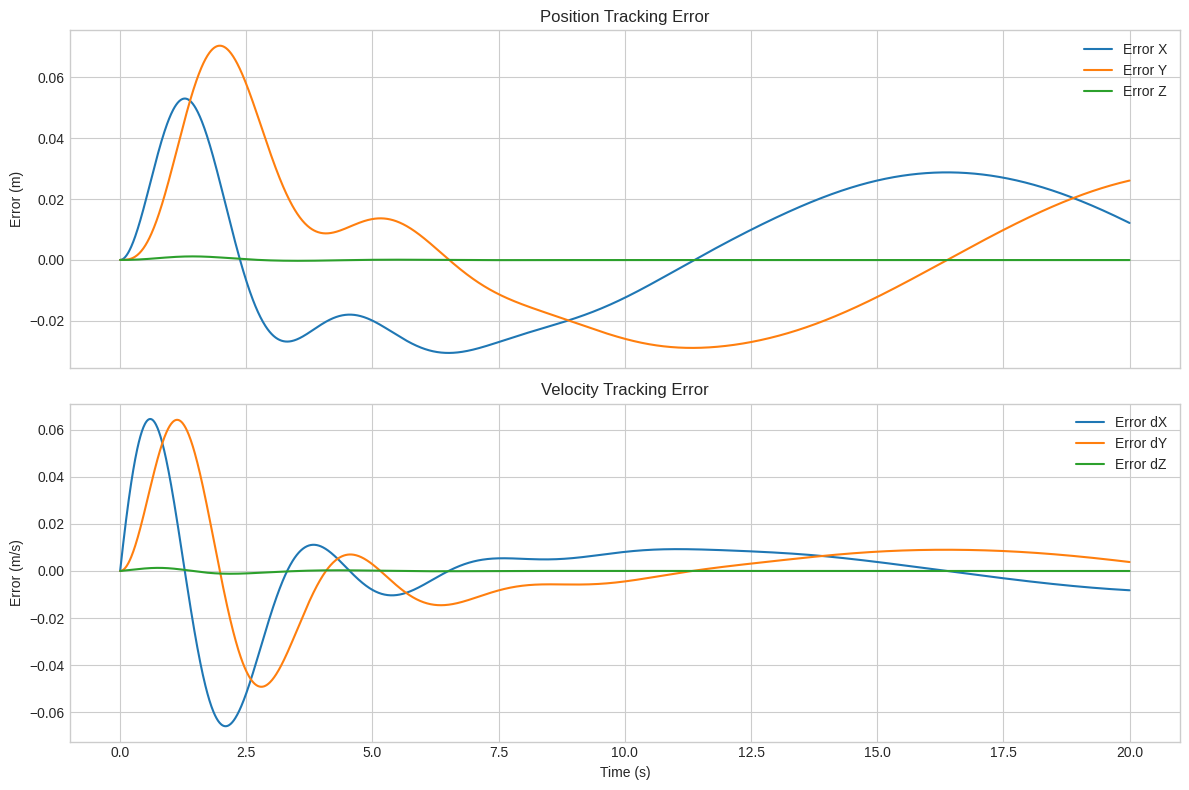

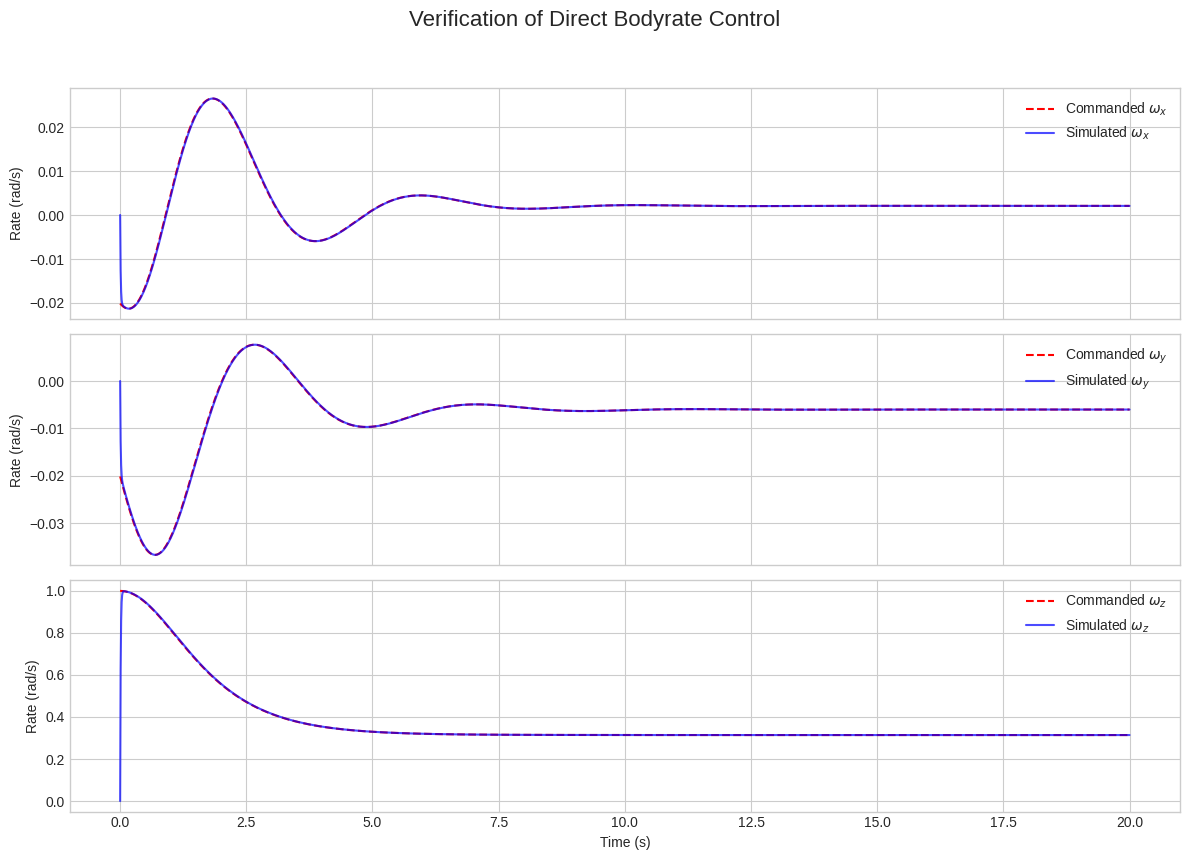

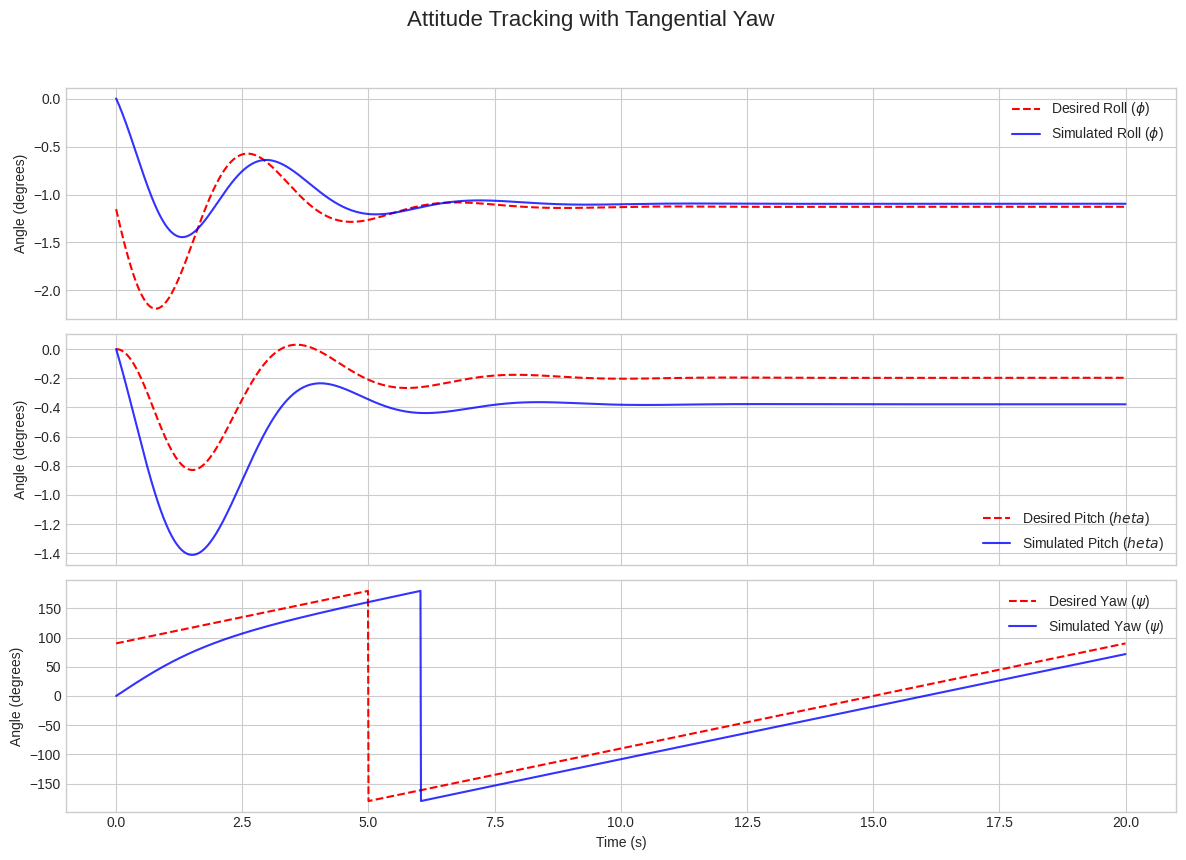

In [30]:
# --- Post-Processing ---
# Get desired trajectory for plotting
r_desired, dr_desired, _ = jax.vmap(circle_reference_func)(ts)

# Extract simulated position and velocity
q_sim = x_hist[:, :3]
dq_sim = x_hist[:, 3:]

# Calculate position and velocity errors
pos_error = q_sim - r_desired
vel_error = dq_sim - dr_desired

# Re-calculate the commanded bodyrate at each step for plotting
@jax.jit
def get_omega_cmd(z_flat, t):
    x, R_flat, _ = z_unravel_func(z_flat)
    q, dq = x[:3], x[3:]
    R = R_flat.reshape((3,3))
    r, dr, ddr = circle_reference_func(t)
    e, de = q - r, dq - dr
    s = de + Lambda_mat @ e
    v, dv = dr - Lambda_mat @ e, ddr - Lambda_mat @ de
    H, C, g, B = prior(q, dq)
    tau = H @ dv + C @ v + g - K_mat @ s
    u_d = jnp.linalg.solve(B, tau)
    
    # --- Apply the same logic change here ---
    f_d = jnp.linalg.norm(u_d)
    b_3d = u_d / (f_d + 1e-6)
    b_1d_desired = dr / (jnp.linalg.norm(dr) + 1e-6)
    b_2d_temp = jnp.cross(b_3d, b_1d_desired)
    b_2d = b_2d_temp / (jnp.linalg.norm(b_2d_temp) + 1e-6)
    b_1d = jnp.cross(b_2d, b_3d)
    R_d = jnp.column_stack((b_1d, b_2d, b_3d))
    # --- End of change ---

    e_R = 0.5 * vee(R_d.T @ R - R.T @ R_d)
    return -k_R * e_R

# Helper function to get the desired attitude R_d at each timestep
@jax.jit
def get_desired_attitude(z_flat, t):
    x, R_flat, _ = z_unravel_func(z_flat)
    q, dq = x[:3], x[3:]
    R = R_flat.reshape((3,3))
    r, dr, ddr = circle_reference_func(t)
    e, de = q - r, dq - dr
    s = de + Lambda_mat @ e
    v, dv = dr - Lambda_mat @ e, ddr - Lambda_mat @ de
    H, C, g, B = prior(q, dq)
    tau = H @ dv + C @ v + g - K_mat @ s
    u_d = jnp.linalg.solve(B, tau)
    
    # --- Apply the same logic change here ---
    f_d = jnp.linalg.norm(u_d)
    b_3d = u_d / (f_d + 1e-6)
    b_1d_desired = dr / (jnp.linalg.norm(dr) + 1e-6)
    b_2d_temp = jnp.cross(b_3d, b_1d_desired)
    b_2d = b_2d_temp / (jnp.linalg.norm(b_2d_temp) + 1e-6)
    b_1d = jnp.cross(b_2d, b_3d)
    R_d = jnp.column_stack((b_1d, b_2d, b_3d))
    # --- End of change ---
    
    return R_d

# Calculate histories for plotting
Omega_cmd_hist = jax.vmap(get_omega_cmd)(z_history_flat, ts)
R_d_hist = jax.vmap(get_desired_attitude)(z_history_flat, ts)
R_sim_hist = R_flat_hist.reshape(-1, 3, 3)

# Helper function to convert rotation matrices to Euler angles
def batch_rotm_to_euler(R_matrices):
    return Rotation.from_matrix(R_matrices).as_euler('xyz', degrees=True)

euler_d_hist = batch_rotm_to_euler(np.asarray(R_d_hist))
euler_sim_hist = batch_rotm_to_euler(np.asarray(R_sim_hist))


# --- Plotting (This section remains the same) ---
print("📊 Generating plots...")

# Plot 1: 3D Trajectory
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(q_sim[:, 0], q_sim[:, 1], q_sim[:, 2], label='Simulated Trajectory', lw=2)
ax.plot(r_desired[:, 0], r_desired[:, 1], r_desired[:, 2], 'r--', label='Desired Trajectory')
ax.set_title('3D Trajectory Tracking')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.legend()
ax.axis('equal')
plt.show()

# Plot 2: Position and Velocity Errors
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axs[0].plot(ts, pos_error[:, 0], label='Error X'); axs[0].plot(ts, pos_error[:, 1], label='Error Y'); axs[0].plot(ts, pos_error[:, 2], label='Error Z')
axs[0].set_title('Position Tracking Error'); axs[0].set_ylabel('Error (m)'); axs[0].legend()
axs[1].plot(ts, vel_error[:, 0], label='Error dX'); axs[1].plot(ts, vel_error[:, 1], label='Error dY'); axs[1].plot(ts, vel_error[:, 2], label='Error dZ')
axs[1].set_title('Velocity Tracking Error'); axs[1].set_xlabel('Time (s)'); axs[1].set_ylabel('Error (m/s)'); axs[1].legend()
plt.tight_layout(); plt.show()

# Plot 3: Bodyrate Tracking Verification
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Verification of Direct Bodyrate Control', fontsize=16)
rate_labels = ['$\omega_x$', '$\omega_y$', '$\omega_z$']
for i in range(3):
    axs[i].plot(ts, Omega_cmd_hist[:, i], 'r--', label=f'Commanded {rate_labels[i]}')
    axs[i].plot(ts, Omega_hist[:, i], 'b-', label=f'Simulated {rate_labels[i]}', alpha=0.7)
    axs[i].set_ylabel('Rate (rad/s)'); axs[i].legend()
axs[2].set_xlabel('Time (s)'); plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# Plot 4: Attitude Tracking (Euler Angles)
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Attitude Tracking with Tangential Yaw', fontsize=16)
angle_labels = ['Roll ($\phi$)', 'Pitch ($\theta$)', 'Yaw ($\psi$)']
for i in range(3):
    axs[i].plot(ts, euler_d_hist[:, i], 'r--', label=f'Desired {angle_labels[i]}')
    axs[i].plot(ts, euler_sim_hist[:, i], 'b-', label=f'Simulated {angle_labels[i]}', alpha=0.8)
    axs[i].set_ylabel('Angle (degrees)'); axs[i].legend()
axs[2].set_xlabel('Time (s)'); plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()